In [1]:
import pandas as pd
import ast
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from datetime import time
from matplotlib import pyplot as plt
from copy import copy
from tqdm.autonotebook import tqdm

C:\Users\Valya\AppData\Local\Temp\ipykernel_4112\377062502.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:
"""
1) Выгрузить больше данных
2) Откоррективать скрипты (выгрузка, обработка, обучение, проверка в песочнице)
3) Перенести в коллаб
4) Добавить вычисление потенциальной доходности до в проверки в песочнице
5) Бустинг посмотреть
6) стопор от ухода в минус
"""

In [2]:
# Задача
"""
Даны катировки актива за предыщие delta_t шагов (разница по времени между шагами в наших данных - 1 минута)
Мы хотим предсказать, что в следующие delta_t_future шагов цена получит относительный прирост на k процентов (это 1),
если условие не выполняется то 0.

Данные:
 csv: для одной акции промежуто за 60 дней (используем цену открытия и время)
 
"""

'\nДаны катировки актива за предыщие delta_t шагов (разница по времени между шагами в наших данных - 1 минута)\nМы хотим предсказать, что в следующие delta_t_future шагов цена получит относительный прирост на k процентов (это 1),\nесли условие не выполняется то 0.\n\nДанные:\n csv: для одной акции промежуто за 60 дней (используем цену открытия и время)\n\n'

In [2]:
path_df = 'C:/Users/Valya/.vscode/Bot/market_data_cache/BBG004730N88/CANDLE_INTERVAL_1_MIN-1765185840-1770369780.csv' # Сбер
epochs = 25
batch_size = 300
delta_t = 100
delta_t_future = 100
k = 0.1

### Data

In [3]:
class MyParquetDataset(Dataset):
    def __init__(self, path_df, delta_t, delta_t_future, k):
        df = pd.read_csv(path_df)
        df = df[pd.to_datetime(df['time']).dt.hour != time(23)]
        df = df.sort_values('time').reset_index(drop=True)

        # 2. Преобразование времени в формат datetime
        df['second'] = pd.to_datetime(df['time']).dt.time.apply(lambda x: x.hour * 3600 + x.minute * 60 + x.second)

        # 3. Функция для парсинга странной строки в число
        def convert_to_float(val):
            # Превращаем строку "{'units':...}" в реальный словарь Python
            data = ast.literal_eval(val)
            # Считаем итоговое значение: units + nano / 10^9
            return data['units'] + data['nano'] / 1e9

        # Применяем функцию к колонке open
        df['open'] = df['open'].apply(convert_to_float)
        df['predict_bool'] = (df['open'].rolling(window=delta_t_future+1).max().shift(-delta_t_future)-df['open']) / df['open']*100 > k

        label_columns_features = []

        for t in range(0, delta_t):
            df[f'normal_price_{t}'] = df['open'].shift(t)
            label_columns_features.append(f'normal_price_{t}')
            
        # Убираем первые строки с Nan
        df = df.iloc[delta_t:-delta_t_future]
        
        # Разделяем данные (зависит от структуры вашего CSV)
        # Предположим, последний столбец 'target' — это то, что мы предсказываем
        X_data = df[label_columns_features].values
        y_data = df['predict_bool'].values
        
        # Превращаем в тензоры
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.float32).reshape(-1, 1)

        print('====>', self.X.shape, self.y.shape)
        #print(self.X)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def split_data(dataset, train_part=0.8):
    len_ds = len(dataset)
    train_size = int(train_part * len_ds)
    
    train_ds = copy(dataset)
    train_ds.X, train_ds.y = train_ds.X[:train_size], train_ds.y[:train_size]
    
    test_ds = copy(dataset)
    test_ds.X, test_ds.y = test_ds.X[train_size:], test_ds.y[train_size:]

    return train_ds, test_ds

In [4]:
full_ds = MyParquetDataset(path_df, delta_t, delta_t_future, k)

====> torch.Size([62302, 100]) torch.Size([62302, 1])


C:\Users\Valya\AppData\Local\Temp\ipykernel_4112\3588126951.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'normal_price_{t}'] = df['open'].shift(t)


In [7]:
print(full_ds)

(tensor([306.4000, 306.4400, 306.3800, 306.3800, 306.3100, 306.2700, 306.2500,
        306.1900, 306.2200, 306.1800, 306.0000, 305.8700, 305.6800, 305.9300,
        306.1900, 306.0500, 306.1200, 305.6900, 306.5100, 306.5200, 306.4900,
        306.4800, 306.4700, 306.4500, 306.4400, 306.4800, 306.4800, 306.4400,
        306.4500, 306.4100, 306.4200, 306.4200, 306.4000, 306.3900, 306.3600,
        306.3400, 306.1200, 306.1000, 306.1300, 306.0900, 306.1000, 306.0800,
        306.0800, 306.0700, 306.1100, 306.0400, 306.0600, 305.9900, 306.0200,
        305.9800, 306.0000, 306.0700, 306.0800, 306.0600, 306.1100, 306.0600,
        306.0000, 306.2500, 306.3100, 306.3600, 306.3100, 306.2400, 306.3900,
        306.3200, 306.3300, 306.3500, 306.3500, 306.1500, 306.1900, 306.1600,
        306.1000, 306.1300, 306.0900, 306.2100, 306.3000, 306.3100, 306.2900,
        306.3000, 306.2000, 306.2200, 306.2000, 306.2400, 306.2700, 306.1200,
        306.1300, 306.1400, 306.0500, 306.0100, 305.9600, 306.0

In [6]:
def check_balance(ds):
    print(f'Num posivives: {(ds.y > 0).sum()} / negatives: {(ds.y == 0).sum()}')

In [7]:
train_ds, test_ds = split_data(full_ds, train_part=0.8)

In [8]:
len(full_ds), len(train_ds), len(test_ds)

(62302, 49841, 12461)

In [9]:
check_balance(full_ds)
check_balance(train_ds)
check_balance(test_ds)

Num posivives: 27223 / negatives: 35079
Num posivives: 21595 / negatives: 28246
Num posivives: 5628 / negatives: 6833


In [10]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

### Model

In [21]:
class MyModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=512):
        super().__init__()
        # Линейный слой: принимает input_dim признаков, выдает 1 число
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.linear3 = nn.Linear(hidden_dim, 1)
        # Сигмоида превращает любое число в вероятность от 0 до 1
        self.sigmoid = nn.Sigmoid()
        self.silu = nn.SiLU()
        self.bn = nn.BatchNorm1d(num_features=input_dim)

    def forward(self, x):
        x = self.bn(x)
        x = self.silu(self.linear1(x))
        x = self.silu(self.linear2(x))
        x = self.sigmoid(self.linear3(x))
        return x

In [ ]:
# Модель берем из предыдущего примера (input_dim = кол-во колонок в X)
model = MyModel(input_dim=train_ds.X.shape[1])

### Train Loop

In [23]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0)
criterion = torch.nn.BCELoss()

In [44]:
from torchmetrics.classification import BinaryAUROC
auc = BinaryAUROC()

def calc_metrics(preds, true, threshold=0.5):
    plabels = (preds > threshold).float()

    tp = (plabels * true).sum()
    tn = ((1-plabels) * (1-true)).sum()
    fp = (plabels * (1 - true)).sum()
    fn = ((1-plabels) * true).sum()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)

    print(f"tp: {tp:.2f} /tn: {tn:.2f} / fp: {fp:.2f} / fn: {fn:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"ROC-AUC: {auc(preds, true):.2f}")

In [27]:
epochs = 100

In [28]:
S = 300
# Цикл обучения по батчам
for epoch in range(epochs):
    model.train()
    for batch_X, batch_y in tqdm(train_loader):
        optimizer.zero_grad()
        outputs = model(batch_X - S)
        loss = criterion(outputs, batch_y)
       
        loss.backward()
        optimizer.step()
        
    print(f'Эпоха [{epoch+1}/{epochs}], Ошибка: {loss.item():.4f}')
        
    # validation
    model.eval()
    
    all_preds = []
    all_true = []
    with torch.no_grad():
        for batch_X, batch_y in tqdm(test_loader):
            outputs = model(batch_X - S)
            all_preds.extend(outputs)
            all_true.extend(batch_y)

    all_preds = torch.cat(all_preds)
    all_true = torch.cat(all_true)
    
    # print(all_preds)
    # print(all_true)
    calc_metrics(all_preds, all_true)

  0%|          | 0/167 [00:00<?, ?it/s]

Эпоха [1/100], Ошибка: 0.6493


  0%|          | 0/42 [00:00<?, ?it/s]

tp: 3875.00 /tn: 1427.00 / fp: 5406.00 / fn: 1753.00
Accuracy: 0.43
Precision: 0.42
Recall: 0.69
ROC-AUC: 0.47


  0%|          | 0/167 [00:00<?, ?it/s]

...

Эпоха [31/100], Ошибка: 0.6412


  0%|          | 0/42 [00:00<?, ?it/s]

tp: 1360.00 /tn: 5862.00 / fp: 971.00 / fn: 4268.00
Accuracy: 0.58
Precision: 0.58
Recall: 0.24
ROC-AUC: 0.58


  0%|          | 0/167 [00:00<?, ?it/s]


KeyboardInterrupt



In [29]:
from sklearn.metrics import roc_curve, auc

In [30]:
fpr, tpr, _ = roc_curve(all_true.numpy(), all_preds.numpy())

In [31]:
roc_auc = auc(fpr, tpr)

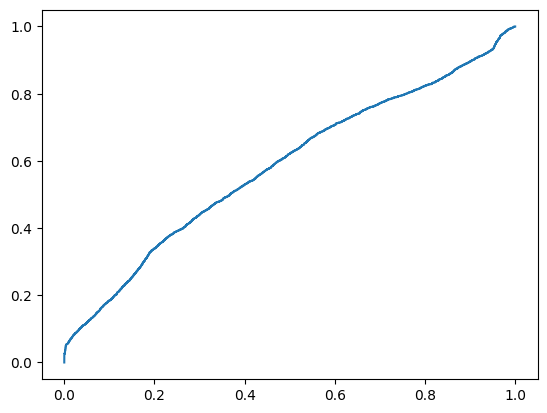

In [33]:
plt.plot(fpr, tpr)

In [32]:
roc_auc

0.583018116958433

In [35]:
idx = torch.argsort(all_preds, descending=True)

In [36]:
spreds, strue = all_preds[idx], all_true[idx]

In [37]:
len(spreds)

12461

In [46]:
n = int(len(spreds)*0.02)

In [49]:
n

249

In [47]:
npreds, ntrue = spreds[:n], strue[:n]

In [48]:
calc_metrics(npreds, ntrue)

tp: 231.00 /tn: 0.00 / fp: 18.00 / fn: 0.00
Accuracy: 0.93
Precision: 0.93
Recall: 1.00
ROC-AUC: 0.74


In [50]:
0.02 * 250 * 0.87

4.35